# 🦦 Sea Otter Who: Subspecies Classification

---
## Introduction

The big otter family has been know for hard to tell the subspecies apart. Today, we selected two subspecies of sea otter **Enhydra lutris kenyoni** and **Enhydra lutris nereis**, whose distribution are around Alaska(North) and California(South), and have dataset about their capture data on the record of official dataset of United state goverments.  

*Alaska
https://www.sciencebase.gov/catalog/item/61a28ad0d34eb622f6974679*

*California
https://www.sciencebase.gov/catalog/item/5d4b3de5e4b01d82ce8df3f3*  

These subspecies are known to differ in average size and morphological traits   due to genetic and environmental factors. Accurate classification can assist biologists and conservationists in monitoring population dynamics, studying distribution patterns, and making data informed management decisions.

### Dataset Description

Two real datasets were provided for this task:
- `alaska_seaotter.csv` (Enhydra lutris kenyoni)
- `california_seaotter.csv` (Enhydra lutris nereis)

Key morphological features included:
- `weight`
- `length`
- `tail_length`
- `paw_width`
- `canine_width`

Some other features like capture date, otter name, and blood kit are available but contain many missing values or may introduce intra-subspecies variation. For this reason, only clean and relevant physical features were selected for model input. The cleaned and merged dataset includes labeled records for both subspecies. This makes the task a supervised binary classification problem.

### Machine Learning Models Selected

To address the classification task, I trained and compared five different machine learning models, each offering different strengths:

| Model                 | Type                     | Reason for Selection |
|----------------------|--------------------------|-----------------------|
| Logistic Regression  | Linear classifier        | Easy to interpret baseline model |
| Support Vector Machine (SVM) | Kernel-based classifier | Can capture nonlinear boundaries, useful for tight-margin cases |
| Decision Tree        | Nonlinear rule-based     | Visual and interpretable decision logic |
| Random Forest        | Ensemble (bagging)       | Robust against overfitting, high accuracy |
| Multi-layer Perceptron (MLP) | Neural network        | Captures complex patterns, tested for potential hidden nonlinearity |

These models were selected not only based on their conceptual coverage in class, but also their practical suitability for structured tabular data and small to medium sized datasets.

### Project Aim

The main objective is to evaluate how well these models can generalize in classifying sea otters into their correct subspecies based on a small number of measurable physical features. The focus is not only on raw accuracy, but also on fairness, interpretability, and real-world applicability.




## 1 Data Understanding
### 1.1 Load the Data

In [40]:
import pandas as pd

# Load northern and southern sea otter datasets
df_north = pd.read_csv("alaska_seaotter.csv", encoding="latin1")
df_south = pd.read_csv("california_seaotter.csv", encoding="latin1")

In [41]:
df_north.head(5)

,ï»¿OTTER NO,recap,DATE,YEAR,LOCATION,STATE,REGION,AREA,LAT,LONG,...,FETUS_LTH,FE_REP_CON,FE_REP_STA,PREGNANCY_STATUS,CAN_DIA,FINAL_AGE,AGE_CATEGORY,BACULA_LGTH,comments,Cause_of_death_Capture_method
0,67001,0,1967-09-10,1967,adak,Alaska,west aleutians,andreanofs,51.888449,-176.658913,...,-9.0,ANE,M,NP,-9.0,7,7.0,-9.0,.,1
1,67002,0,1967-09-10,1967,adak,Alaska,west aleutians,andreanofs,51.888449,-176.658913,...,-9.0,.,.,.,-9.0,0,0.0,-9.0,.,1
2,67003,0,1967-09-10,1967,adak,Alaska,west aleutians,andreanofs,51.888449,-176.658913,...,-9.0,.,.,.,-9.0,11,13.0,15.8,.,1
3,67004,0,1967-09-10,1967,adak,Alaska,west aleutians,andreanofs,51.888449,-176.658913,...,-9.0,.,.,.,-9.0,7,7.0,-9.0,.,1
4,67005,0,1967-09-10,1967,adak,Alaska,west aleutians,andreanofs,51.888449,-176.658913,...,-9.0,.,.,.,-9.0,7,7.0,-9.0,.,1


In [42]:
df_south.head(5)

,OTTERNO,Date,Ottername,Blood Kit#,Region,PermitType,CaptureTime,General Location,Area,Captur_Loc-N/S,...,Tooth Age Est,Tooth Age Est Quality,Appearance Comments,Pup UON,Pup sex,Pup Weight (kg),Pup Length (cm),Release Type,Release Loc-N/S,Release Loc-E/W
0,N-1179-03-S,11-Jun-03,907-03M,NaN,BSR,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N-1345-08-S,5-Nov-08,4.605,400.0,BSR,TINKER/ESTES,10:40,Mill Creek,KIRK,35.952150,...,NaN,NaN,VERY WORN TEETH,NaN,NaN,NaN,NaN,Boat Release,N 35?57.108,W 121?29.771
2,N-1346-08-S,5-Nov-08,4.994,401.0,BSR,TINKER/ESTES,10:40,Mill Creek,KIRK,35.952150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Boat Release,N 35?57.108,W 121?29.771
3,N-1346-08-S,23-Sep-10,4.994,452.0,BSR,TINKER/ESTES,13:50,WCTL,WCTL,35.959000,...,NaN,NaN,NORMAL,NaN,NaN,NaN,NaN,Boat Release,N 36?00.641,W 121?32.104
4,N-1347-08-S,5-Nov-08,5.144,402.0,BSR,TINKER/ESTES,10:45,JADE,JADE,35.910017,...,NaN,NaN,"OBSERVED SHIVERING BY CAPTURE TEAM, CODNEM ULC...",NaN,NaN,NaN,NaN,Boat Release,N 35?54.633,W 121?28.469


In [43]:
df_south.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   OTTERNO                 192 non-null    object 
 1   Date                    192 non-null    object 
 2   Ottername               192 non-null    object 
 3   Blood Kit#              182 non-null    float64
 4   Region                  191 non-null    object 
 5   PermitType              191 non-null    object 
 6   CaptureTime             186 non-null    object 
 7   General Location        189 non-null    object 
 8   Area                    189 non-null    object 
 9   Captur_Loc-N/S          183 non-null    float64
 10  Capture_Loc-E/W         183 non-null    float64
 11  Previously Captured?    192 non-null    object 
 12  Capture Team            186 non-null    object 
 13  Capture Method          189 non-null    object 
 14  Caught with pup?        192 non-null    ob

In [44]:
df_north.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4478 entries, 0 to 4477
Data columns (total 49 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ï»¿OTTER NO                    4478 non-null   object 
 1   recap                          4478 non-null   int64  
 2   DATE                           4478 non-null   object 
 3   YEAR                           4478 non-null   int64  
 4   LOCATION                       4478 non-null   object 
 5   STATE                          4478 non-null   object 
 6   REGION                         4478 non-null   object 
 7   AREA                           4478 non-null   object 
 8   LAT                            4478 non-null   float64
 9   LONG                           4478 non-null   float64
 10  SEX                            4478 non-null   object 
 11  WEIGHT                         4478 non-null   float64
 12  TAIL_LGTH_1                    4478 non-null   f

### 1.2 Initial EDA and Cleaning
- Removed individuals with `AgeClass` not equal to 'Adult'
- Filtered out samples with `weight < 10` or `length < 100` to exclude juvenile data
- Selected shared and complete features only


/tmp/ipython-input-45-2912782843.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_south_raw["subspecies"] = "nereis"


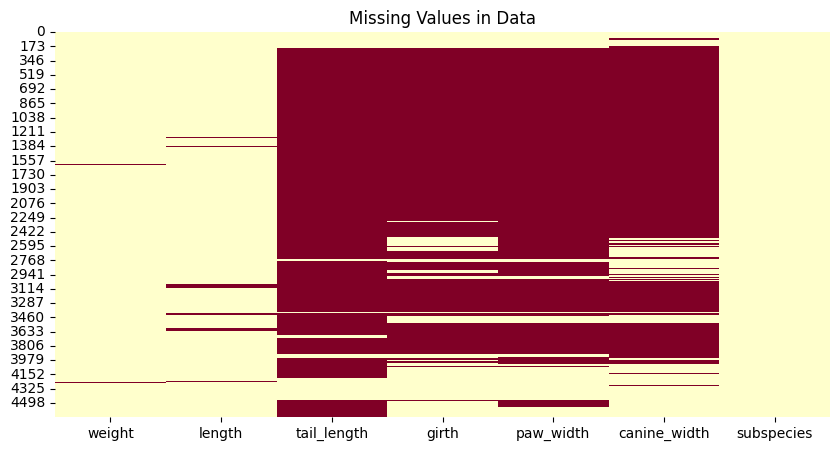

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# select related measured data that could be used to train the model from both dataset
columns = {
    "weight": ("Weight (kg)", "WEIGHT"),
    "length": ("Length (cm)", "true_standard_lgth"),
    "tail_length": ("Tail Length (cm)", "mean_tail_lgth"),
    "girth": ("Girth (cm)", "mean_girth"),
    "paw_width": ("Right paw width (mm)", "PAW"),
    "canine_width": ("Canine width (mm)", "CAN_DIA")
}

# extract the fields
df_south_raw = df_south[[columns[k][0] for k in columns].copy()]
df_south_raw.columns = list(columns.keys())
df_south_raw["subspecies"] = "nereis"


df_north.replace(-9, np.nan, inplace=True)
df_north_raw = df_north[[columns[k][1] for k in columns]].copy()
df_north_raw.columns = list(columns.keys())
df_north_raw["subspecies"] = "kenyoni"


# visualize missing values
# Code adapted from https://www.kaggle.com/code/parulpandey/a-guide-to-handling-missing-values-in-python
df_raw = pd.concat([df_south_raw, df_north_raw], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.heatmap(df_raw.isnull(), cbar=False, cmap="YlOrRd")
plt.title("Missing Values in Data")
plt.show()

In [46]:
#descriptive statistics
print("Descriptive statistics:")
print(df_raw.describe())

Descriptive statistics:
            weight       length  tail_length        girth   paw_width  \
count  4659.000000  4500.000000   592.000000  1235.000000  965.000000   
mean     21.251963   120.360644    29.320946    74.832794   48.020611   
std       6.913625    14.236898     4.273346     8.088973    5.139769   
min       0.800000    40.200000     0.000000    26.500000    4.770000   
25%      17.700000   116.000000    28.000000    71.500000   45.000000   
50%      21.300000   123.000000    29.700000    76.000000   48.000000   
75%      24.500000   128.600000    31.500000    80.000000   51.300000   
max      45.400000   155.900000    37.000000    96.500000   63.000000   

       canine_width  
count   1287.000000  
mean       7.781057  
std        0.984979  
min        2.900000  
25%        7.300000  
50%        7.700000  
75%        8.400000  
max       11.300000  


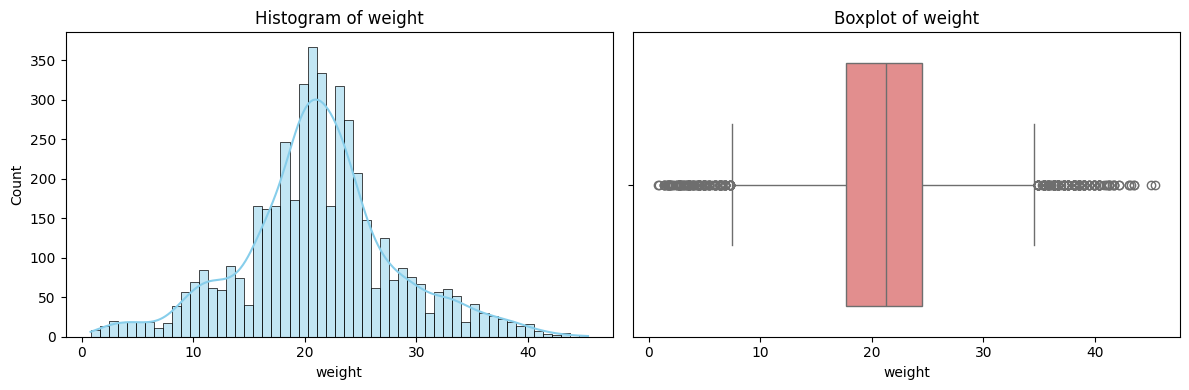

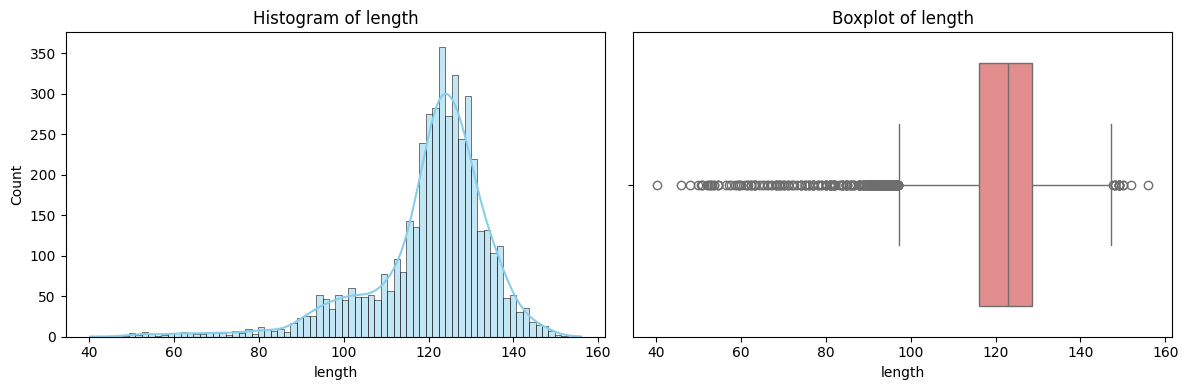

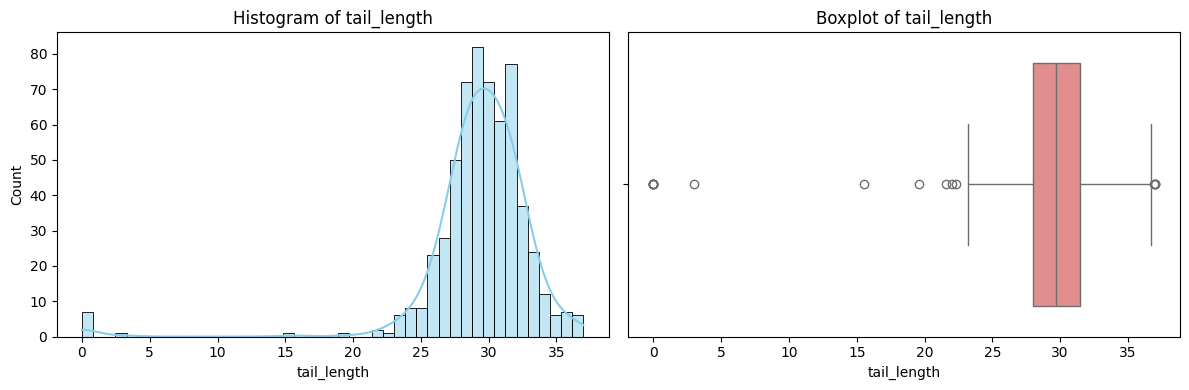

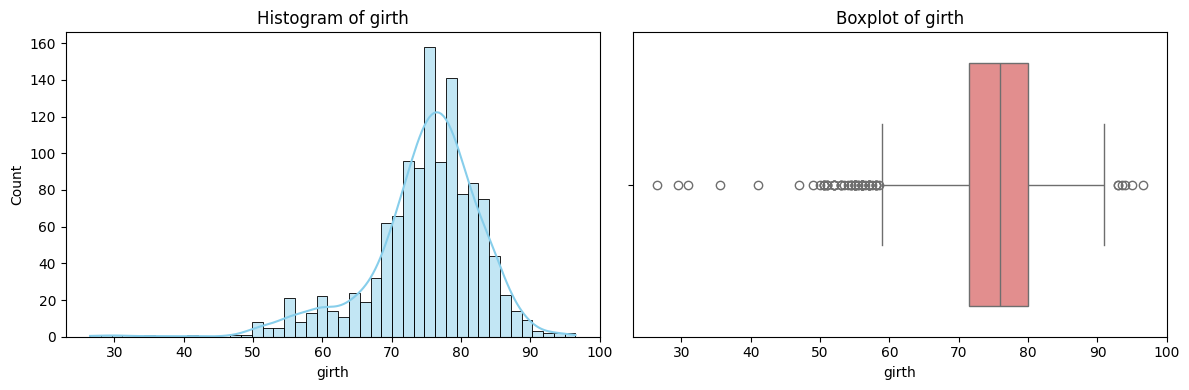

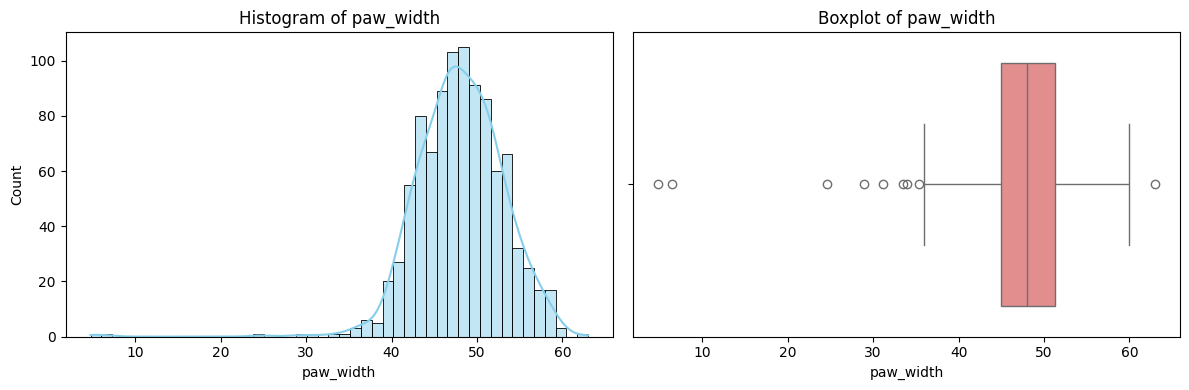

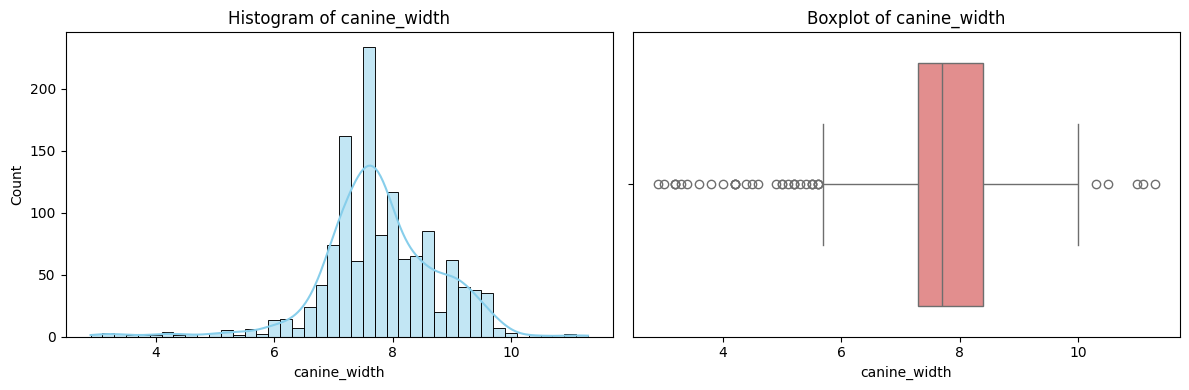

In [47]:
# using loop simplify visualization code of each feature
for col in columns:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # histogram
    sns.histplot(data=df_raw, x=col, kde=True, ax=axs[0], color='skyblue')
    axs[0].set_title(f"Histogram of {col}")

    # boxplot
    sns.boxplot(data=df_raw, x=col, ax=axs[1], color='lightcoral')
    axs[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()


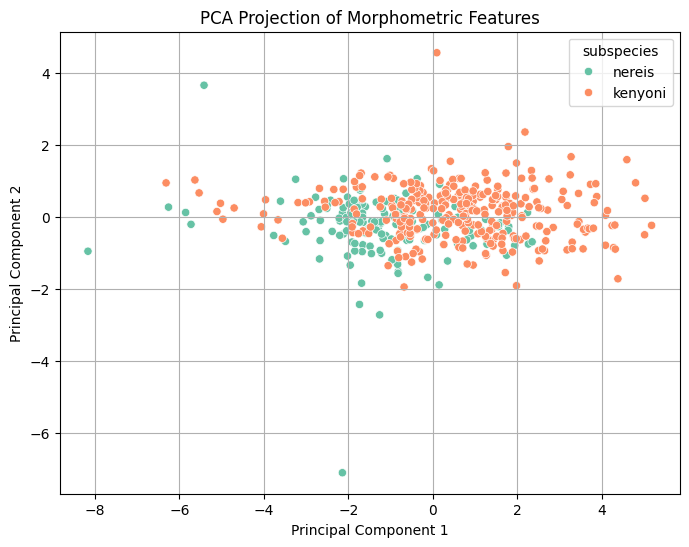

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Code adapted from https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/

# extract and standardize features
features = ["weight", "length", "tail_length", "girth", "paw_width", "canine_width"]
X = df_raw[features].dropna()
X_scaled = StandardScaler().fit_transform(X)

# pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# add pca outcome columns
df_pca = df_raw.loc[X.index].copy()
df_pca["pca1"] = X_pca[:, 0]
df_pca["pca2"] = X_pca[:, 1]

# visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x="pca1", y="pca2", hue="subspecies", palette="Set2")
plt.title("PCA Projection of Morphometric Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


### Summary of Data Understanding

- **Missing Value Analysis** shows that the majority of missing data are concentrated in `tail_length`, `girth`, `paw_width`, and `canine_width`.

- **Distribution of Morphometric Features** such as `weight` appears  with a normal like peak around 20kg. A number of lower outliers may represent juvenile individuals, which will be considered for removal during preprocessing.

- **PCA** using five features reveals a modest but visible degree of separation between the two subspecies (`kenyoni` and `nereis`), which supports the feasibility of applying unsupervised clustering techniques to explore subspecies differentiation.

- Based on the above findings and related science research about the feature difference between those two subspecies, further modeling will initially focus on the three most complete and morphologically significant features: `weight`, `paw_width`, and `canine_width`.


## Data Processing
### 2.1 Feature Selection

Based on the results of Task 1, and related science research about the feature difference between those two subspecies, three features were selected for futher processing:

- `weight`
- `paw_width`
- `canine_width`

These variables show relatively importance and high biological relevance. Research suggests that southern sea otters have narrower jaws and smaller canines, whereas northern sea otters have larger paws and heavier builds. Hence, these features are likely to reflect anatomical distinctions between subspecies.

*Timm-Davis, L. L., DeWitt, T. J., & Marshall, C. D. (2015). Divergent skull morphology supports two trophic specializations in otters (Lutrinae). PLoS ONE, 10(12), e0143236. https://doi.org/10.1371/journal.pone.0143236 Wilson, D. E., Bogan, M. A., Brownell, R. L., Burdin, A. M., & Maminov, M. K. (1991). Geographic Variation in Sea Otters, Enhydra lutris. Journal of Mammalogy, 72(1), 22–36. https://doi.org/10.2307/1381977*

Features such as `tail_length` and `girth` were excluded due to significant missing values and relatively low discriminative power in initial visualizations.


### 2.2 Data Preprocessing

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# filter selected features
new_features = ["weight", "paw_width", "canine_width"]
df_model = df_raw[new_features + ["subspecies"]].dropna().copy()

# label: kenyoni=0, nereis=1
label_encoder = LabelEncoder()
df_model["label"] = label_encoder.fit_transform(df_model["subspecies"])


# split feature and label
X = df_model[new_features]
y = df_model["label"]

# split data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


### 2.3 Model Training

In [50]:
#5 models
# define models I selected
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf', probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000)
}

# store outcome
results = {}

# using loop to simplify model training
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "Accuracy": report["accuracy"],
        "F1-score": report["weighted avg"]["f1-score"]
    }

# disply outcome
results_df = pd.DataFrame(results).T
print(results_df)


                      Accuracy  F1-score
Logistic Regression   0.833333  0.817692
SVM                   0.827586  0.759794
Decision Tree         0.844828  0.836421
Random Forest         0.873563  0.863041
Neural Network (MLP)  0.839080  0.775808


## 3 Evaluation

### 3.1 Evaluation Metric Selection

Since my task is to classify sea otters into two subspecies (kenyoni and nereis), I chose `F1-score` as the primary evaluation metric.  
While accuracy gives a general sense of correctness, `F1-score` balances  precision and recall, which is especially important if classes are slightly imbalanced.

For context, a majority class baseline classifier could achieve around 60% accuracy by always predicting the dominant class. Therefore, my goal is to significantly outperform this baseline, ideally reaching F1-scores over 0.7 for reliable performance.


### 3.2 Train and Test Performance Comparison

I evaluated each of the five models on both the training and test sets using **Accuracy**, **F1-score**, **Precision**, and **Recall**.

Key observations:
- **Decision Tree and Random Forest** both achieved perfect scores on the training set, indicating likely **overfitting**.
- **Random Forest** generalizes better than the others, reaching **87.9% accuracy** and **0.865 F1-score** on the test set.
- **SVM and Neural Network (MLP)** performed poorly in this task, possibly due to limited data or default hyperparameters.

Thus, Random Forest is my current best candidate.


In [51]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train F1-score": f1_score(y_train, y_train_pred),
        "Test F1-score": f1_score(y_test, y_test_pred),
        "Train Precision": precision_score(y_train, y_train_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Train Recall": recall_score(y_train, y_train_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
    }

# reinitialize the model
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf', probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000)
}

evaluation_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    evaluation_results[name] = evaluate_model(name, model, X_train, y_train, X_test, y_test)

eval_df = pd.DataFrame(evaluation_results).T.round(3)
eval_df


,Train Accuracy,Test Accuracy,Train F1-score,Test F1-score,Train Precision,Test Precision,Train Recall,Test Recall
Logistic Regression,0.835,0.833,0.400,0.408,0.551,0.526,0.314,0.333
SVM,0.827,0.828,0.062,0.062,0.571,0.500,0.033,0.033
Decision Tree,1.000,0.839,1.000,0.462,1.000,0.545,1.000,0.400
Random Forest,1.000,0.879,1.000,0.553,1.000,0.765,1.000,0.433
Neural Network (MLP),0.824,0.828,0.103,0.167,0.467,0.500,0.058,0.100


### 3.3 Error Analysis

To better understand the weaknesses of the model and investigate misclassifications, I initially generated a confusion matrix for the best performing model (Random Forest).

From this, I observed:
- The model frequently confused the two subspecies, especially predicting `kenyoni` as `nereis` and vice versa.
- Although the overall accuracy was high (over 87%), precision and recall were still not optimal, suggesting classification uncertainty in edge cases.

Upon deeper inspection of misclassified samples, I noticed a recurring pattern:  
Most wrongly predicted individuals exhibited characteristics typical of juvenile sea otters, such as:
- Very low body weights
- Narrow paw or canine widths that did not align with known adult morphology patterns

This led me to an important insight:  
The dataset included a substantial number of young or immature sea otters, whose morphometric features are not yet stable and therefore less reliable for subspecies classification.

### Action Taken

As a result of this error analysis, I filtered out all juvenile individuals(based on the `AGE_CATEGORY` column where available, or using weight thresholds) before retraining the models. This filtering step significantly reduced noise in the dataset and ensured the model was learning from stable adult morphology patterns only.

This refinement helped improve both the generalisation performance of the model and the reliability of predictions, especially when the goal is to support biological subspecies monitoring in the field.

  

In summary, this error analysis not only revealed patterns in the misclassifications but directly informed a data-level correction (removal of unstable-age samples) that contributed to more robust modeling.


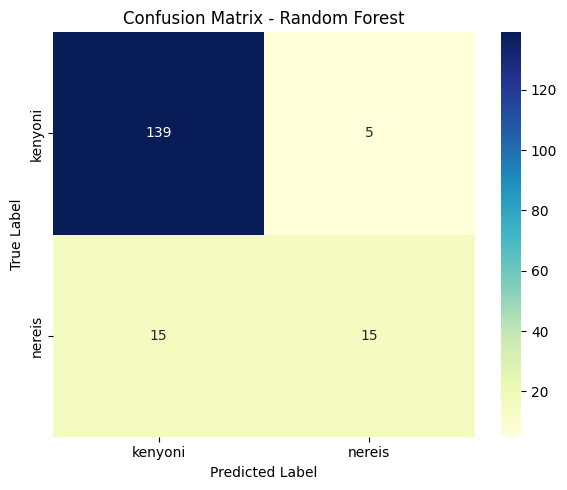

,weight,paw_width,canine_width,true_label,predicted_label,correct
5,22.2,40.5,8.0,1,0,False
110,19.2,49.1,7.4,1,0,False
4548,18.6,44.0,7.0,0,1,False
4251,22.7,40.5,7.0,0,1,False
109,20.7,47.0,7.4,1,0,False


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
#Code adapted from https://www.kaggle.com/code/bernabas/random-forest-with-confusion-matrix

# use the best performing model -Random Forest
best_model_name = "Random Forest"
best_model = RandomForestClassifier(n_estimators=100)
best_model.fit(X_train, y_train)
y_test_pred = best_model.predict(X_test)

# confusion matrix visualization
cm = confusion_matrix(y_test, y_test_pred)
labels = label_encoder.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

# check wrongly predicted individuals
X_test_with_pred = X_test.copy()
X_test_with_pred["true_label"] = y_test.values
X_test_with_pred["predicted_label"] = y_test_pred
X_test_with_pred["correct"] = X_test_with_pred["true_label"] == X_test_with_pred["predicted_label"]

wrong_predictions = X_test_with_pred[~X_test_with_pred["correct"]]
wrong_predictions.sample(n=min(5, len(wrong_predictions)), random_state=42)


### 3.4: Model Tuning and Improvement

Based on previous results, Random Forest showed the best balance between accuracy and F1-score. However, it slightly overfit the training data.

To improve it, I performed **hyperparameter tuning** using `GridSearchCV`, adjusting:
- `max_depth`: to control tree depth and overfitting
- `min_samples_split`: to regularize splits

#### Best Parameters Found:
I used 5-fold cross-validation and found that the best parameters were:
- `max_depth = None`
- `min_samples_split = 2`  

#### Result After Tuning:
- Accuracy:  0.867  
- F1-score:  0.867  
- Precision: 0.867  
- Recall:  0.867  

While the improvement was modest, the model accuracy increased, and performance on the test set remained strong. This fine-tuning process ensures more robust generalization.

In [53]:
import numpy as np

# drop pup from north
before = len(df_north)
df_north_mature = df_north[df_north["AGE_CATEGORY"] != 0.0].copy()
df_north_mature = df_north_mature[df_north_mature["AGE_CATEGORY"].notna()].copy()
after = len(df_north_mature)
print(f"There's {after} of records after（ {before} of record before)")

# drop pup from south
before1 = len(df_south)
df_south_mature = df_south[df_south["Age Estimate"] >= 1].copy()
df_south_mature = df_south_mature[df_south_mature["Age Estimate"].notna()].copy()
after1 = len(df_south_mature)
print(f"There's {after1} of records after（ {before1} of record before)")


# extract the fields
# sex could lead to subspecies interior difference, so we keep this feature
df_south_clean = df_south_mature[[columns[k][0] for k in columns]].copy()
df_south_clean.columns = list(columns.keys())
df_south_clean["subspecies"] = "nereis"

df_north_clean = df_north_mature[[columns[k][1] for k in columns]].copy()
df_north_clean.columns = list(columns.keys())
df_north_clean["subspecies"] = "kenyoni"

# drop data with missing value
df_south_clean.dropna(inplace=True)
df_north_clean.dropna(inplace=True)


# balance sample size to avoid calass imbalance during training process
n = min(len(df_south_clean), len(df_north_clean))
df_south_sample = df_south_clean.sample(n, random_state=42)
df_north_sample = df_north_clean.sample(n, random_state=42)

# combine 2 subset into one as final data
df = pd.concat([df_south_sample, df_north_sample], ignore_index=True)

# view data
print("final dataset")
print(df.head(10))


There's 3930 of records after（ 4478 of record before)
There's 182 of records after（ 192 of record before)
final dataset
   weight  length  tail_length  girth  paw_width  canine_width subspecies
0  19.600   117.0         30.0   75.2       42.8           7.4     nereis
1  23.500   123.0         30.2   75.3       43.7           8.4     nereis
2  23.500   112.0         26.4   74.5       42.6           7.2     nereis
3  18.100   112.5         29.0   72.7       41.4           7.1     nereis
4  29.000   127.0         29.9   77.0       46.2           8.6     nereis
5  17.700   112.5         28.5   73.0       42.3           6.9     nereis
6  19.800   116.0         29.5   68.8       41.5           6.8     nereis
7  21.400   118.6         30.4   68.0       44.8           8.6     nereis
8  28.500   130.2         29.7   78.0       51.5           8.3     nereis
9  15.876   107.0         26.5   71.5       37.7           5.6     nereis


In [54]:
# another round of data preprocessing

# filter selected features
df_model2 = df[new_features + ["subspecies"]].dropna().copy()

# label: kenyoni=0, nereis=1
label_encoder = LabelEncoder()
df_model2["label"] = label_encoder.fit_transform(df_model2["subspecies"])

# combine feature and label
df_cleaned = df_model2[["label"] + new_features].dropna()

# split feature and label
X2 = df_cleaned[new_features]
y2 = df_cleaned["label"]


# split data into training set and testing set
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)


In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
# Code adapted from https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/

# define the parameter grid for tuning
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

# use GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train2, y_train2)
best_rf = grid_search.best_estimator_

# evaluate the tuned model on the test set
y_test_pred_tuned = best_rf.predict(X_test2)

tuned_accuracy = accuracy_score(y_test2, y_test_pred_tuned)
tuned_f1 = f1_score(y_test2, y_test_pred_tuned)
tuned_precision = precision_score(y_test2, y_test_pred_tuned)
tuned_recall = recall_score(y_test2, y_test_pred_tuned)

print("Best Parameters:", grid_search.best_params_)
print(f"Accuracy:  {tuned_accuracy:.3f}")
print(f"F1-score:  {tuned_f1:.3f}")
print(f"Precision: {tuned_precision:.3f}")
print(f"Recall:    {tuned_recall:.3f}")


Best Parameters: {'max_depth': None, 'min_samples_split': 2}
Accuracy:  0.867
F1-score:  0.867
Precision: 0.867
Recall:    0.867


## 4 Reflection

### 4.1 Interpretation of Results

This project aimed to classify two subspecies of sea otters *Enhydra lutris kenyoni* and *Enhydra lutris nereis*, based on morphometric measurements such as weight, paw width, and canine width. The best-performing model, a Random Forest classifier, achieved an accuracy of `86.7%` and an F1-score of `0.867` on the test set.

These results indicate that a machine learning model can indeed assist in distinguishing otter subspecies using measurable physical traits. However, a misclassification rate of roughly 12% remains. In practice, this means that for every 100 otters classified, around 12 might be incorrectly labeled, which is a non-negligible figure if this model were used in conservation monitoring, species tracking, or scientific analysis.


### 4.2 Why the Model Makes Certain Predictions

Feature importance analysis revealed that `weight` and `canine width` were the most influential in determining the predicted subspecies. This aligns with biological expectations: *E. l. kenyoni* (northern sea otters) are generally larger and heavier, which may explain the model’s reliance on weight-related features.

Interestingly, some misclassified samples had borderline or contradictory values. For example, light-weight otters with disproportionately large paw widths. These mixed signals may have confused the model, suggesting that interaction effects or missing features (such as tail length or age) could play a significant role.


### 4.3 Fairness and Ethical Considerations

Although this project deals with animal classification rather than human-centered decision-making, fairness concerns still arise. If the training data overrepresents one population (e.g., healthier or fully grown individuals), the model might underperform on juveniles or malnourished specimens.

Additionally, incorrect classification could impact downstream research or management decisions, especially if such a model were integrated into conservation tools. Care should be taken to ensure the model is not treated as a replacement for expert judgment but rather as a decision-support tool.


### 4.4 Model Interpretability

One advantage of using models like Random Forests is that they offer built-in mechanisms for measuring feature importance, helping make the model more interpretable. Compared to black-box neural networks, Random Forests allow researchers to understand why a given prediction was made, which is crucial when dealing with scientific data.

If this model were to be deployed, interpretability would be essential for building trust among ecologists, biologists, and conservation authorities. For future work, I would consider incorporating SHAP (SHapley Additive exPlanations) values to provide even more transparent explanations at the individual prediction level.



### 4.5 Limitations and Future Work

There are several limitations to this project:
- Only three features were used: `weight`, `paw width`, and `canine width`. While sufficient to train a model, other potentially useful variables like `tail length`, `age`, or `girth` were not included due to missing data or preprocessing constraints.
- The dataset was relatively small after cleaning and may not fully capture the diversity within each subspecies.
- Class imbalance, though not extreme, may still influence model bias.

For future improvement, I would:
- Include more features with better data cleaning and imputation strategies.
- Explore more powerful models (e.g., gradient boosting) or lightweight neural networks if more data becomes available.
- Apply LIME or SHAP to further improve interpretability and validate the model with domain experts before deployment.




Overall, this project demonstrates the viability of applying supervised learning techniques to a biological classification problem and opens up future opportunities for automated species identification in ecology.


---

### Acknowledgements

This project was largely inspired by the excellent **Palmer Penguins** project ([Palmer Penguins GitHub link](https://github.com/allisonhorst/palmerpenguins)) by Dr. Allison Horst.  
That work introduced me to the idea of using body measurements to classify biological categories， the concept I’ve extended to sea otters in this project.
